# 03 - Comprehensive Regularization Techniques for ANNs in PyTorch

This notebook covers **all major regularization techniques** used to prevent overfitting and improve generalization in Feedforward Neural Networks:

---

## Regularization Methods Covered:

1. **L2 Regularization (Weight Decay)**: Optimizer penalty on $\|W\|_2^2$.
2. **L1 Regularization (Lasso)**: Explicit loss penalty on $\|W\|_1$ promoting sparsity.
3. **Dropout**: Random neuron masking during training (`nn.Dropout`).
4. **Batch Normalization**: Internal covariate shift reduction (`nn.BatchNorm1d`).
5. **Layer Normalization**: Instance-wise feature normalization (`nn.LayerNorm`).
6. **Data Augmentation / Input Noise**: Adding Gaussian noise to inputs.
7. **Early Stopping**: Halting training when validation loss stops improving.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import copy

import torch
import torch.nn as nn
import torch.optim as torch_optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
torch.manual_seed(42)

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')


## 1. Dataset & Baseline Setup

We generate a noisy dataset prone to overfitting to demonstrate the impact of regularization.


In [2]:
X_raw, y_raw = make_classification(
    n_samples=600,
    n_features=40,
    n_informative=15,
    n_redundant=15,
    n_classes=2,
    flip_y=0.15,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(X_raw, y_raw, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_train)
X_v_s = scaler.transform(X_val)

X_train_t = torch.tensor(X_tr_s, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t = torch.tensor(X_v_s, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=32, shuffle=False)


## 2. L2 Regularization (Weight Decay)

L2 regularization modifies the loss objective:
$$\mathcal{L}_{\text{total}} = \mathcal{L}_{\text{CE}} + \frac{\lambda}{2} \sum_{w} w^2$$
In PyTorch, this is directly passed to the optimizer via `weight_decay`.


In [3]:
class StandardNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(40, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )
    def forward(self, x):
        return self.net(x)

# Model with L2 Regularization
model_l2 = StandardNet()
criterion = nn.CrossEntropyLoss()
optimizer_l2 = torch_optim.Adam(model_l2.parameters(), lr=0.001, weight_decay=1e-2) # L2 penalty


## 3. L1 Regularization (Lasso & Sparsity)

L1 regularization penalizes absolute weights:
$$\mathcal{L}_{\text{total}} = \mathcal{L}_{\text{CE}} + \lambda \sum_{w} |w|$$
Since PyTorch optimizers do not have a built-in `l1_decay`, we compute it manually during the loss step.


In [4]:
def train_with_l1(model, train_loader, val_loader, epochs=80, l1_lambda=1e-3):
    optimizer = torch_optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    
    val_losses = []
    for epoch in range(epochs):
        model.train()
        for bx, by in train_loader:
            optimizer.zero_grad()
            out = model(bx)
            loss = criterion(out, by)
            
            # Compute L1 norm across all linear parameters
            l1_penalty = sum(p.abs().sum() for name, p in model.named_parameters() if 'weight' in name)
            total_loss = loss + l1_lambda * l1_penalty
            
            total_loss.backward()
            optimizer.step()
            
        model.eval()
        with torch.no_grad():
            v_loss = sum(criterion(model(bx), by).item() * len(by) for bx, by in val_loader) / len(val_loader.dataset)
            val_losses.append(v_loss)
            
    return val_losses

model_l1 = StandardNet()
val_losses_l1 = train_with_l1(model_l1, train_loader, val_loader, epochs=80, l1_lambda=1e-3)


## 4. Dropout Regularization (`nn.Dropout`)

Dropout randomly zeros activations during training with probability $p$. It scales remaining active weights by $\frac{1}{1-p}$ (Inverted Dropout).

> **Crucial Rule**: You MUST call `model.train()` during training and `model.eval()` during inference!


In [6]:
class DropoutNet(nn.Module):
    def __init__(self, p=0.4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(40, 128),
            nn.ReLU(),
            nn.Dropout(p=p), # Dropout layer 1
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(p=p), # Dropout layer 2
            nn.Linear(64, 2)
        )
    def forward(self, x):
        return self.net(x)

# Demonstrating train vs eval mode effect on single batch
model_drop = DropoutNet(p=0.5)
sample_x = X_train_t[:3]

model_drop.train()
print("Outputs in TRAIN mode (Dropout Active):")
print(model_drop(sample_x))

model_drop.eval()
print("Outputs in EVAL mode (Dropout Disabled):")
print(model_drop(sample_x))


Outputs in TRAIN mode (Dropout Active):
tensor([[ 0.1810,  0.3887],
        [-0.0301,  0.4668],
        [ 0.1169,  0.0483]], grad_fn=<AddmmBackward0>)
Outputs in EVAL mode (Dropout Disabled):
tensor([[ 0.1691,  0.2399],
        [-0.0781,  0.2037],
        [ 0.0403,  0.1016]], grad_fn=<AddmmBackward0>)


## 5. Batch Normalization & Layer Normalization

- **Batch Normalization (`nn.BatchNorm1d`)**: Normalizes feature channels across the batch dimension.
- **Layer Normalization (`nn.LayerNorm`)**: Normalizes feature channels per individual sample.


In [7]:
class BatchNormNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(40, 128)
        self.bn1 = nn.BatchNorm1d(128) # BatchNorm
        self.relu1 = nn.ReLU()
        
        self.fc2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)
        self.relu2 = nn.ReLU()
        
        self.out = nn.Linear(64, 2)
        
    def forward(self, x):
        x = self.relu1(self.bn1(self.fc1(x)))
        x = self.relu2(self.bn2(self.fc2(x)))
        return self.out(x)

class LayerNormNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(40, 128),
            nn.LayerNorm(128), # LayerNorm
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )
    def forward(self, x):
        return self.net(x)

print("BatchNorm Architecture:", BatchNormNet())


BatchNorm Architecture: BatchNormNet(
  (fc1): Linear(in_features=40, out_features=128, bias=True)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu2): ReLU()
  (out): Linear(in_features=64, out_features=2, bias=True)
)


## 6. Early Stopping Implementation

`EarlyStopping` tracks validation loss and restores the model's best weights if validation loss does not improve for `patience` consecutive epochs.


In [10]:
class EarlyStopping:
    def __init__(self, patience=10, min_delta=1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = float('inf')
        self.best_model_weights = None
        self.early_stop = False

    def check(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.best_model_weights = copy.deepcopy(model.state_dict())
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

# Demonstrate Early Stopping in action
early_stopper = EarlyStopping(patience=10)
model_es = StandardNet()
optimizer_es = torch_optim.Adam(model_es.parameters(), lr=0.002)

es_val_losses = []
stopped_epoch = 100

for epoch in range(1, 101):
    model_es.train()
    for bx, by in train_loader:
        optimizer_es.zero_grad()
        loss = criterion(model_es(bx), by)
        loss.backward()
        optimizer_es.step()
        
    model_es.eval()
    with torch.no_grad():
        v_loss = sum(criterion(model_es(bx), by).item() * len(by) for bx, by in val_loader) / len(val_loader.dataset)
        es_val_losses.append(v_loss)
        
    early_stopper.check(v_loss, model_es)
    if early_stopper.early_stop:
        print(f"Early Stopping Triggered at Epoch {epoch}! Restoring best weights...")
        model_es.load_state_dict(early_stopper.best_model_weights)
        stopped_epoch = epoch
        break


Early Stopping Triggered at Epoch 13! Restoring best weights...


## 7. Comparative Analysis of All Regularizers

We benchmark all regularization techniques on the validation set over 80 epochs.


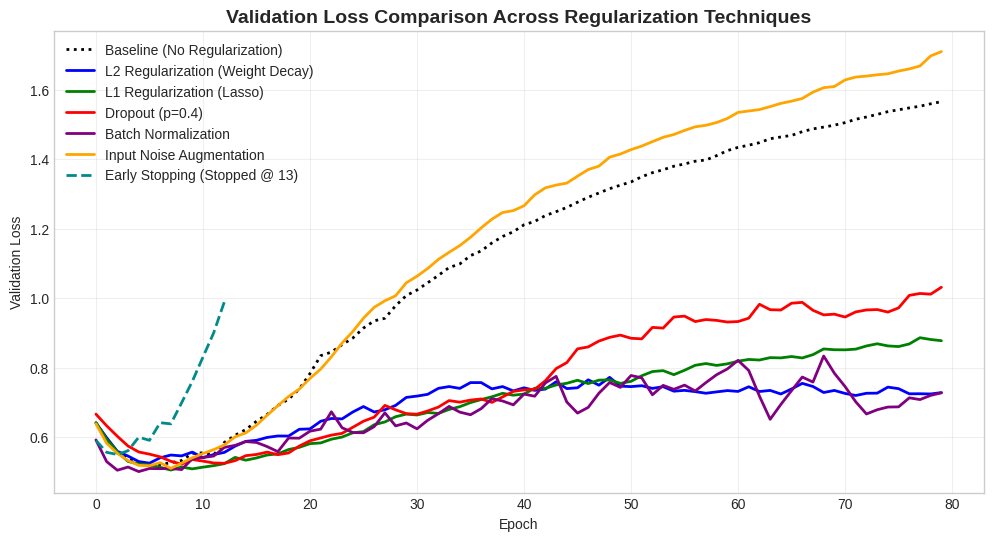

In [11]:
def train_tracker(model, optimizer, train_loader, val_loader, epochs=80, add_noise=False):
    criterion = nn.CrossEntropyLoss()
    val_losses = []
    for epoch in range(epochs):
        model.train()
        for bx, by in train_loader:
            if add_noise:
                bx = bx + torch.randn_like(bx) * 0.1 # Input Gaussian Noise
            optimizer.zero_grad()
            loss = criterion(model(bx), by)
            loss.backward()
            optimizer.step()
            
        model.eval()
        with torch.no_grad():
            v_loss = sum(criterion(model(bx), by).item() * len(by) for bx, by in val_loader) / len(val_loader.dataset)
            val_losses.append(v_loss)
    return val_losses

epochs = 80
base_model = StandardNet()
l2_model = StandardNet()
drop_model = DropoutNet(p=0.4)
bn_model = BatchNormNet()
noise_model = StandardNet()

v_base = train_tracker(base_model, torch_optim.Adam(base_model.parameters(), lr=0.001), train_loader, val_loader, epochs)
v_l2 = train_tracker(l2_model, torch_optim.Adam(l2_model.parameters(), lr=0.001, weight_decay=1e-2), train_loader, val_loader, epochs)
v_drop = train_tracker(drop_model, torch_optim.Adam(drop_model.parameters(), lr=0.001), train_loader, val_loader, epochs)
v_bn = train_tracker(bn_model, torch_optim.Adam(bn_model.parameters(), lr=0.001), train_loader, val_loader, epochs)
v_noise = train_tracker(noise_model, torch_optim.Adam(noise_model.parameters(), lr=0.001), train_loader, val_loader, epochs, add_noise=True)

# Plot comparison
plt.figure(figsize=(12, 6))
plt.plot(v_base, label='Baseline (No Regularization)', color='black', linestyle=':', linewidth=2)
plt.plot(v_l2, label='L2 Regularization (Weight Decay)', color='blue', linewidth=2)
plt.plot(val_losses_l1, label='L1 Regularization (Lasso)', color='green', linewidth=2)
plt.plot(v_drop, label='Dropout (p=0.4)', color='red', linewidth=2)
plt.plot(v_bn, label='Batch Normalization', color='purple', linewidth=2)
plt.plot(v_noise, label='Input Noise Augmentation', color='orange', linewidth=2)
plt.plot(es_val_losses, label=f'Early Stopping (Stopped @ {stopped_epoch})', color='darkcyan', linestyle='--', linewidth=2)

plt.title('Validation Loss Comparison Across Regularization Techniques', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()
